In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

Project Title:

Healthcare Patient Flow Analysis using Exploratory Data Analysis (EDA)

Project Statement:

This project focuses on analyzing healthcare patient flow data using Exploratory Data Analysis (EDA) techniques. The dataset contains important features such as patient age, gender, race, wait time, satisfaction score, admission status, and department referrals, which help in understanding hospital operations and patient behavior.

The dataset was first preprocessed by handling missing values, removing irrelevant columns, and converting categorical variables into suitable formats. Data cleaning and transformation steps were performed to ensure the dataset was ready for analysis.

EDA techniques were then applied to explore the data through statistical summaries and visualizations. Univariate analysis was used to understand the distribution of variables such as age, wait time, and satisfaction score. Bivariate and multivariate analyses were conducted to identify relationships between variables, such as the impact of wait time on patient satisfaction and admission patterns across different departments.

The objective of this project is to uncover meaningful insights, identify patterns and trends in patient flow, and understand key factors affecting patient satisfaction and hospital efficiency. These insights can support better decision-making and serve as a foundation for future machine learning model

In [2]:
df=pd.read_csv("healthcare_analytics_patient_flow_data.csv")

In [3]:
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


In [4]:

total_patient=df["Patient Id"].nunique()
print(total_patient)

9216


In [5]:
df.shape

(9216, 11)

In [6]:
num_cols=df.select_dtypes(include=['int64','float64'])
print(num_cols.head())

   Patient Age  Patient Satisfaction Score  Patient Waittime
0           63                         5.0                32
1           31                         NaN                22
2           75                         NaN                16
3           79                         NaN                38
4           24                         NaN                36


EDA

UNIVARIATE ANALYSIS

In [7]:
df['Patient Age'].describe()

count    9216.000000
mean       39.855143
std        22.755125
min         1.000000
25%        20.000000
50%        39.000000
75%        60.000000
max        79.000000
Name: Patient Age, dtype: float64

In [8]:
df['Patient Satisfaction Score'].describe()


count    2517.000000
mean        4.992054
std         3.138043
min         0.000000
25%         2.000000
50%         5.000000
75%         8.000000
max        10.000000
Name: Patient Satisfaction Score, dtype: float64

In [9]:
df['Patient Waittime'].describe()

count    9216.000000
mean       35.259874
std        14.735323
min        10.000000
25%        23.000000
50%        35.000000
75%        48.000000
max        60.000000
Name: Patient Waittime, dtype: float64

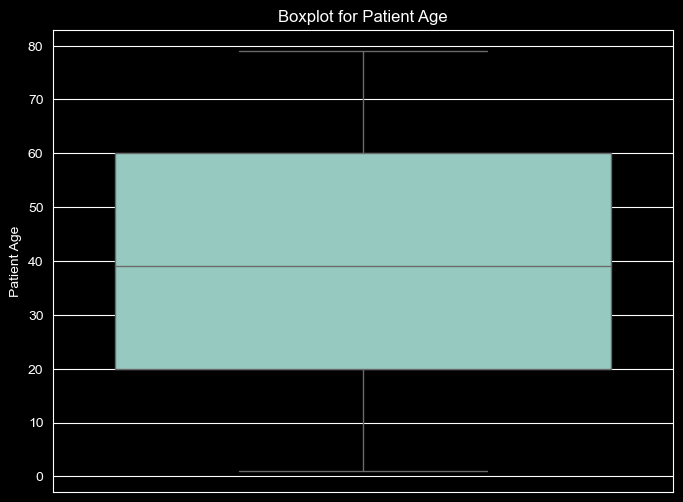

 Boxplot of Patient Age
Patient Age contains continuous numeric values.
- Skewness: 0.01 (right-skewed).
- Most frequent range (middle 50%): 20.00 to 60.00.
- Spread (IQR): 40.00.
- Outliers detected: 0.



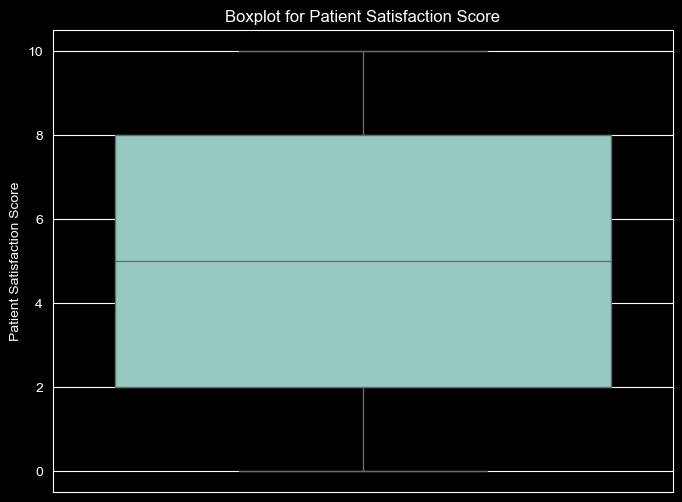

 Boxplot of Patient Satisfaction Score
Patient Satisfaction Score contains continuous numeric values.
- Skewness: -0.01 (left-skewed).
- Most frequent range (middle 50%): 2.00 to 8.00.
- Spread (IQR): 6.00.
- Outliers detected: 0.



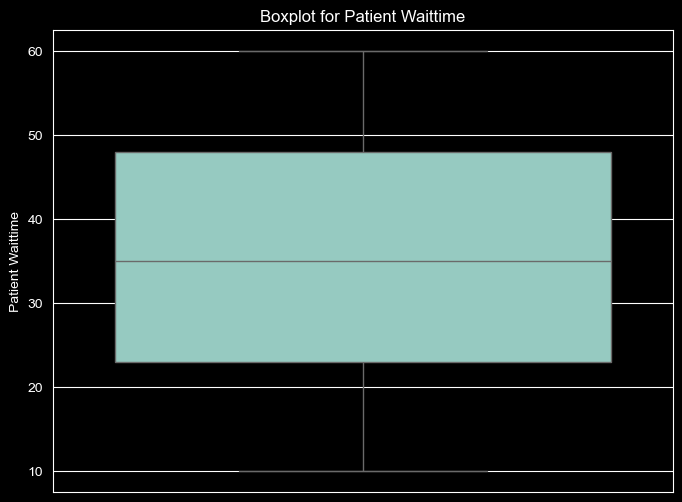

 Boxplot of Patient Waittime
Patient Waittime contains continuous numeric values.
- Skewness: -0.02 (left-skewed).
- Most frequent range (middle 50%): 23.00 to 48.00.
- Spread (IQR): 25.00.
- Outliers detected: 0.



In [10]:
# Numeric column EDA
# Univariate analysis
markdown_output = []

for cols in num_cols:
    data = df[cols].dropna()  # drop NA only for EDA
    unique = data.nunique()
    skewness = data.skew()

    plt.figure(figsize=(8, 6))
    sns.boxplot(y=data)
    plt.title(f"Boxplot for {cols}")
    plt.ylabel(cols)
    plt.show()  # show plot first

    # Calculate stats
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outlier = data[(data < lower) | (data > upper)]

    # Markdown comment
    markdown = (
        f" Boxplot of {cols}\n"
        f"{cols} contains continuous numeric values.\n"
        f"- Skewness: {skewness:.2f} "
        f"({'right-skewed' if skewness > 0 else 'left-skewed' if skewness < 0 else 'Approximately symmetric'}).\n"
        f"- Most frequent range (middle 50%): {q1:.2f} to {q3:.2f}.\n"
        f"- Spread (IQR): {iqr:.2f}.\n"
        f"- Outliers detected: {len(outlier)}.\n"
    )

    print(markdown)  # print after plot
    markdown_output.append(markdown)


In [11]:
cat_cols=df.select_dtypes(include=['object'])
print(cat_cols.head())

    Patient Id Patient Admission Date Patient Admission Time        Merged  \
0  780-96-6113               9/9/2024             9:25:00 AM     W. Breede   
1  714-35-6722               9/9/2024             4:42:00 PM   Y. Baldetti   
2  571-85-3714               9/9/2024            12:14:00 AM    M. Semerad   
3  404-43-9499               9/9/2024             8:33:00 PM    K. Blaydes   
4  552-51-5855               9/9/2024             7:25:00 PM  F. Dickerson   

  Patient Gender      Patient Race Department Referral Patient Admission Flag  
0         Female  African American                 NaN          Not Admission  
1           Male             Asian         Orthopedics          Not Admission  
2           Male             White    General Practice          Not Admission  
3           Male  African American    General Practice              Admission  
4         Female  African American                 NaN              Admission  


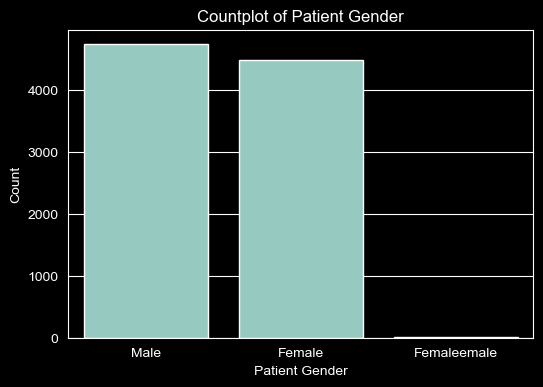

Countplot of Patient Gender
- Total categories: 3
- Most frequent category: Male (4729 counts)
- Least frequent category: Femaleemale (17 counts)
- This bar plot shows the distribution of each category in Patient Gender.



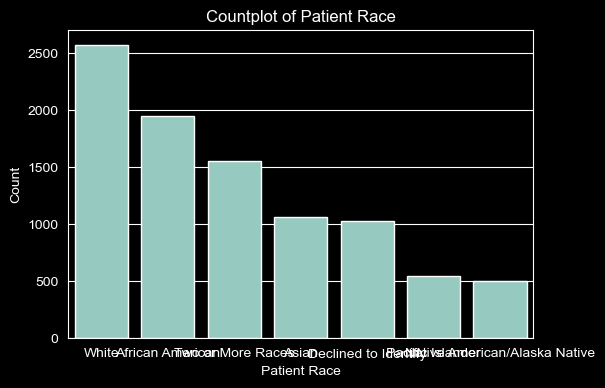

Countplot of Patient Race
- Total categories: 7
- Most frequent category: White (2571 counts)
- Least frequent category: Native American/Alaska Native (498 counts)
- This bar plot shows the distribution of each category in Patient Race.



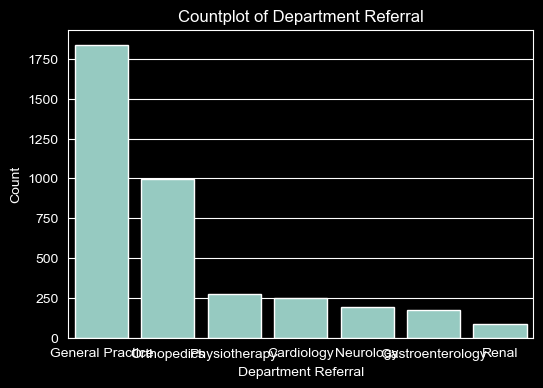

Countplot of Department Referral
- Total categories: 7
- Most frequent category: General Practice (1840 counts)
- Least frequent category: Renal (86 counts)
- This bar plot shows the distribution of each category in Department Referral.



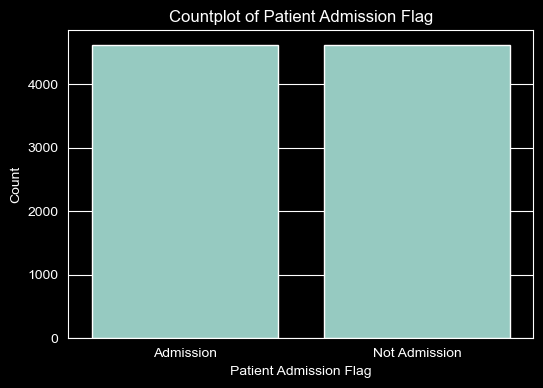

Countplot of Patient Admission Flag
- Total categories: 2
- Most frequent category: Admission (4612 counts)
- Least frequent category: Not Admission (4604 counts)
- This bar plot shows the distribution of each category in Patient Admission Flag.



In [12]:
markdown_output = []
categoric_cols=['Patient Gender','Patient Race','Department Referral','Patient Admission Flag']
for col in categoric_cols:
    data = df[col].dropna()  # drop NA for analysis

    # Frequency counts
    freq = data.value_counts()
    most_freq = freq.idxmax()
    most_freq_count = freq.max()
    least_freq = freq.idxmin()
    least_freq_count = freq.min()

    # Plot
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df, order=freq.index)
    plt.title(f"Countplot of {col}")
    plt.ylabel("Count")
    plt.xlabel(col)
    plt.show()

    # Markdown
    markdown = (
        f"Countplot of {col}\n"
        f"- Total categories: {data.nunique()}\n"
        f"- Most frequent category: {most_freq} ({most_freq_count} counts)\n"
        f"- Least frequent category: {least_freq} ({least_freq_count} counts)\n"
        f"- This bar plot shows the distribution of each category in {col}.\n"
    )
    print(markdown)
    markdown_output.append(markdown)

BIVARIATE ANALYSIS

In [13]:
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient Admission Time',
       'Merged', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime'],
      dtype='object')

In [14]:
#drop features like pateint id,patient admission date,merged,patient admission time
cols_to_exclude = [
    'Patient Id',
    'Patient Admission Date',
    'Patient Admission Time',
    'Merged'
]

new_cols = df.drop(columns=cols_to_exclude)
new_cols.head()


,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,Female,63,African American,NaN,Not Admission,5.0,32
1,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,Male,75,White,General Practice,Not Admission,NaN,16
3,Male,79,African American,General Practice,Admission,NaN,38
4,Female,24,African American,NaN,Admission,NaN,36


# Target Analysis: Patient Admission Flag

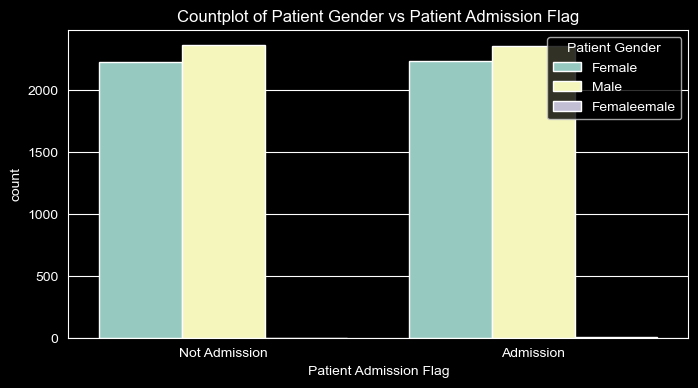

### Countplot of Patient Gender VS Patient Admission Flag
**Frequency Table:**

| Patient Gender   |   Admission |   Not Admission |
|:-----------------|------------:|----------------:|
| Female           |        2239 |            2231 |
| Femaleemale      |          11 |               6 |
| Male             |        2362 |            2367 |

- **Most frequent pair:** ('Male', 'Not Admission')
- **Least frequent pair:** ('Femaleemale', 'Not Admission')


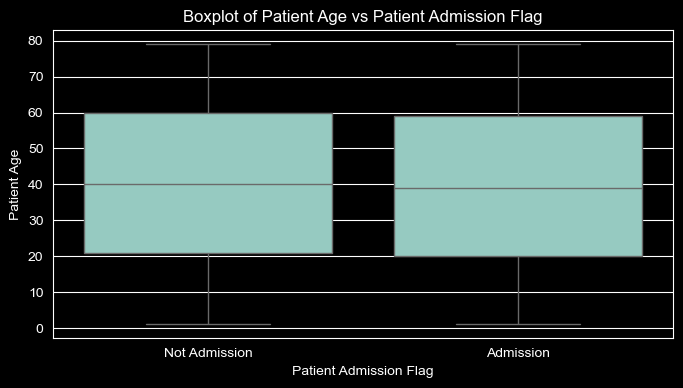

### Boxplot of Patient Age vs Patient Admission Flag
- **Skewness:** 0.01
- **IQR:** 40.00 (Range: 20.00 to 60.00)
- **Outliers detected:** 0


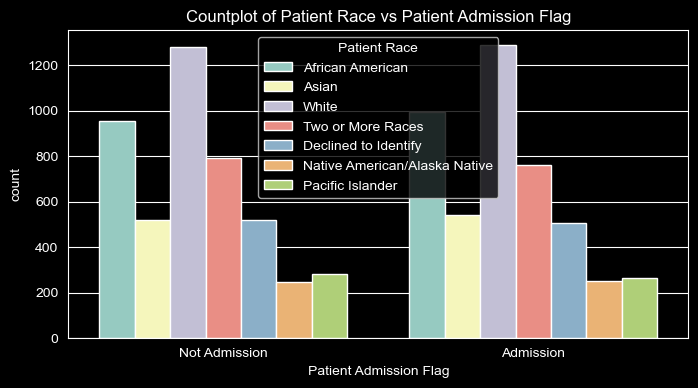

### Countplot of Patient Race VS Patient Admission Flag
**Frequency Table:**

| Patient Race                  |   Admission |   Not Admission |
|:------------------------------|------------:|----------------:|
| African American              |         995 |             956 |
| Asian                         |         541 |             519 |
| Declined to Identify          |         508 |             522 |
| Native American/Alaska Native |         251 |             247 |
| Pacific Islander              |         265 |             284 |
| Two or More Races             |         763 |             794 |
| White                         |        1289 |            1282 |

- **Most frequent pair:** ('White', 'Admission')
- **Least frequent pair:** ('Native American/Alaska Native', 'Not Admission')


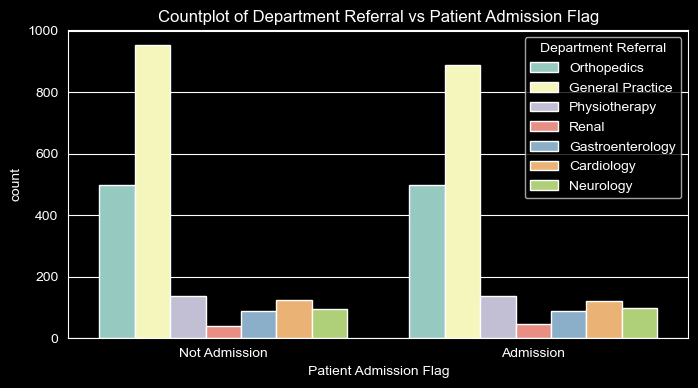

### Countplot of Department Referral VS Patient Admission Flag
**Frequency Table:**

| Department Referral   |   Admission |   Not Admission |
|:----------------------|------------:|----------------:|
| Cardiology            |         122 |             126 |
| Gastroenterology      |          89 |              89 |
| General Practice      |         887 |             953 |
| Neurology             |          97 |              96 |
| Orthopedics           |         498 |             497 |
| Physiotherapy         |         137 |             139 |
| Renal                 |          46 |              40 |

- **Most frequent pair:** ('General Practice', 'Not Admission')
- **Least frequent pair:** ('Renal', 'Not Admission')


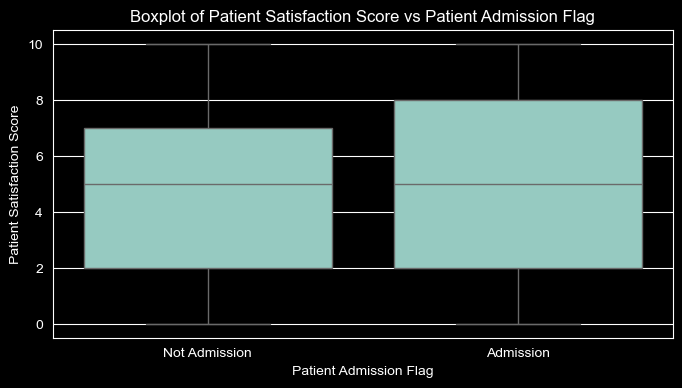

### Boxplot of Patient Satisfaction Score vs Patient Admission Flag
- **Skewness:** -0.01
- **IQR:** 6.00 (Range: 2.00 to 8.00)
- **Outliers detected:** 0


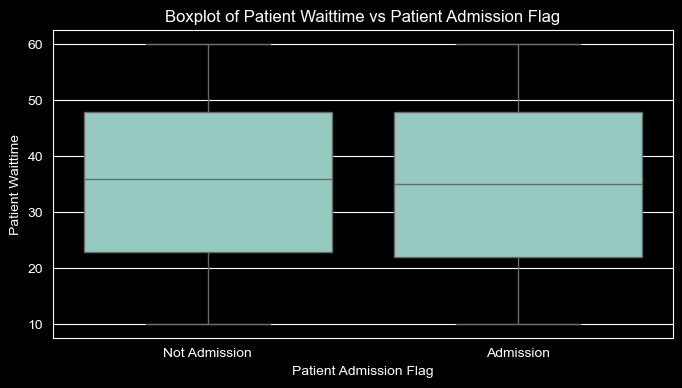

### Boxplot of Patient Waittime vs Patient Admission Flag
- **Skewness:** -0.02
- **IQR:** 25.00 (Range: 23.00 to 48.00)
- **Outliers detected:** 0


# Target Analysis: Patient Satisfaction Score

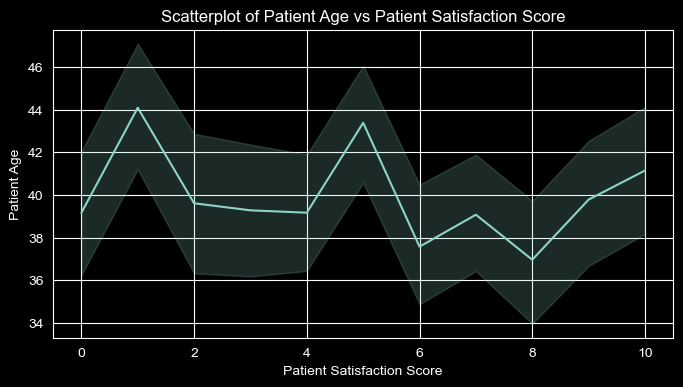

### Analysis of Patient Age VS Patient Satisfaction Score
- **Correlation (Pearson):** -0.02
- **Mean of Patient Age:** 39.86
- **Max Value:** 79


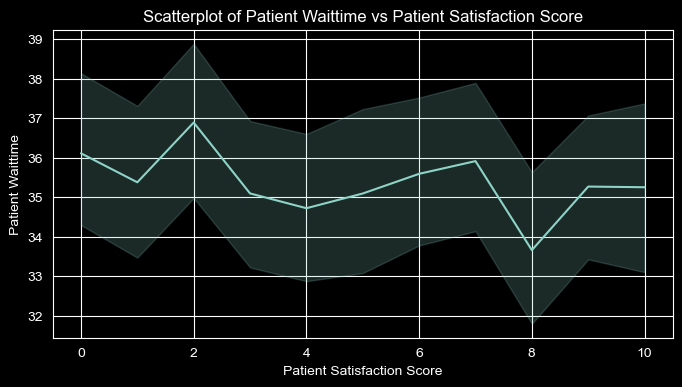

### Analysis of Patient Waittime VS Patient Satisfaction Score
- **Correlation (Pearson):** -0.02
- **Mean of Patient Waittime:** 35.26
- **Max Value:** 60


# Target Analysis: Patient Waittime

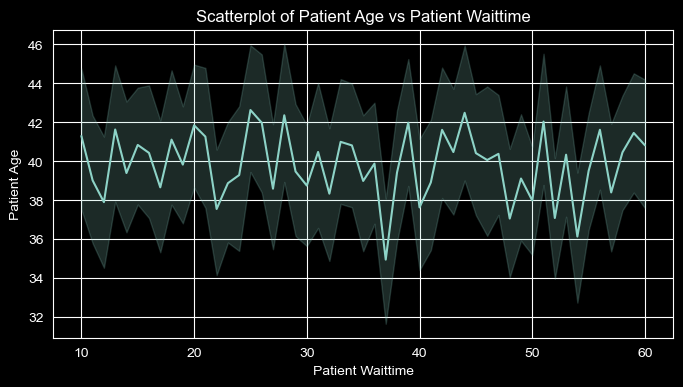

### Analysis of Patient Age VS Patient Waittime
- **Correlation (Pearson):** -0.01
- **Mean of Patient Age:** 39.86
- **Max Value:** 79


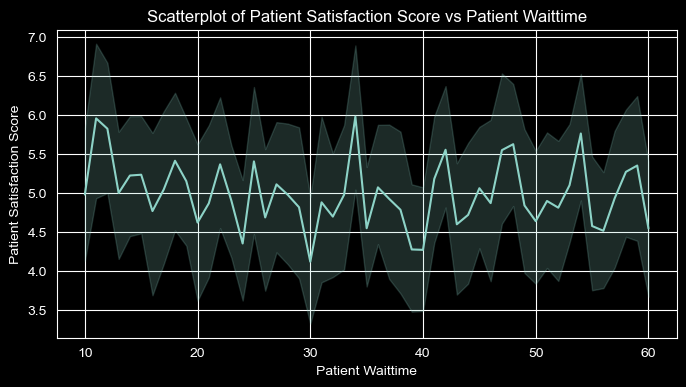

### Analysis of Patient Satisfaction Score VS Patient Waittime
- **Correlation (Pearson):** -0.02
- **Mean of Patient Satisfaction Score:** 4.99
- **Max Value:** 10.0


In [15]:
from IPython.display import display, Markdown
target=['Patient Admission Flag','Patient Satisfaction Score','Patient Waittime']
# Initialize list to store markdown if you want to export it later
markdown_output = []

for t in target:
    display(Markdown(f"# Target Analysis: {t}"))

    if t in cat_cols:  # Case: Categorical Target
        for col in new_cols.columns:
            if col == t: continue

            # 🔹 Categorical Target vs Numerical Feature
            if col in num_cols:
                plt.figure(figsize=(8, 4))
                sns.boxplot(data=df, x=t, y=col)
                plt.title(f"Boxplot of {col} vs {t}")
                plt.show()

                skewness = df[col].skew()
                q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
                iqr = q3 - q1
                outliers = df[(df[col] < (q1 - 1.5 * iqr)) | (df[col] > (q3 + 1.5 * iqr))]

                md = (
                    f"### Boxplot of {col} vs {t}\n"
                    f"- **Skewness:** {skewness:.2f}\n"
                    f"- **IQR:** {iqr:.2f} (Range: {q1:.2f} to {q3:.2f})\n"
                    f"- **Outliers detected:** {len(outliers)}\n"
                )
                display(Markdown(md))
                markdown_output.append(md)

            # 🔹 Categorical Target vs Categorical Feature
            elif col in cat_cols:
                plt.figure(figsize=(8, 4))
                sns.countplot(data=df, x=t, hue=col)
                plt.title(f"Countplot of {col} vs {t}")
                plt.show()

                freq_table = pd.crosstab(df[col], df[t])
                most_freq = freq_table.stack().idxmax()
                least_freq = freq_table.stack().idxmin()

                md = (
                    f"### Countplot of {col} VS {t}\n"
                    f"**Frequency Table:**\n\n{freq_table.to_markdown()}\n\n"
                    f"- **Most frequent pair:** {most_freq}\n"
                    f"- **Least frequent pair:** {least_freq}\n"
                )
                display(Markdown(md))
                markdown_output.append(md)

    elif t in num_cols:  # Case: Numerical Target
        for col in num_cols:
            if col == t: continue

            # 🔹 Numerical Target vs Numerical Feature
            plt.figure(figsize=(8, 4))
            sns.lineplot(data=df, x=t, y=col)
            plt.title(f"Scatterplot of {col} vs {t}")
            plt.show()

            correlation = df[t].corr(df[col])

            md = (
                f"### Analysis of {col} VS {t}\n"
                f"- **Correlation (Pearson):** {correlation:.2f}\n"
                f"- **Mean of {col}:** {df[col].mean():.2f}\n"
                f"- **Max Value:** {df[col].max()}\n"
            )
            display(Markdown(md))
            markdown_output.append(md)

MULTIVARIATE ANALYSIS

In [16]:
#know the category in each columns
columns=df.select_dtypes(include=['object'])
for cols in new_cols:
    uniue=df[cols].nunique()
    if unique>10:
        print(df[cols].value_counts())
    else:continue





Patient Gender
Male           4729
Female         4470
Femaleemale      17
Name: count, dtype: int64
Patient Age
39    145
49    142
27    142
56    139
18    139
     ... 
20    101
1     101
44    100
21    100
75    100
Name: count, Length: 79, dtype: int64
Patient Race
White                            2571
African American                 1951
Two or More Races                1557
Asian                            1060
Declined to Identify             1030
Pacific Islander                  549
Native American/Alaska Native     498
Name: count, dtype: int64
Department Referral
General Practice    1840
Orthopedics          995
Physiotherapy        276
Cardiology           248
Neurology            193
Gastroenterology     178
Renal                 86
Name: count, dtype: int64
Patient Admission Flag
Admission        4612
Not Admission    4604
Name: count, dtype: int64
Patient Satisfaction Score
7.0     256
4.0     248
1.0     246
6.0     231
3.0     228
0.0     222
9.0     222
5.0     2

In [17]:
#converting object type to numeirc value
#Patient Waittime,Pateint Age,Patient Satisfaction Score
df['Patient Waittime'] = pd.to_numeric(df['Patient Waittime'])
df['Patient Satisfaction Score']=pd.to_numeric(df['Patient Satisfaction Score'])
df['Patient Age']=pd.to_numeric(df['Patient Age'])

In [18]:
#encoding
#for admission
admission_map={
    'Admission':1,
    'Not Admission':0
}
#for departement referral
referral_map={
    'General Practice':1,
    'Orthopedics':2,
    'Physiotherapy':3,
    'Cardiology':4,
    'Neurology':5,
    'Gatroenterology':6,
    'Renal':7
}
#for patient gender
gender_map={
    'Male':0,
    'Female':1,
    'Femalemalw':2
}
#for races
race_map={
    'White':0,
    'African American':1,
    'Two or More Races':2,
    'Asian':3,
    'Declined to Identify':6,
    'Pacific Islander':7,
    'Native American/Alaska Native':8
}
df['Patient Admission Flag'] = df['Patient Admission Flag'].map(admission_map)
df['Patient Gender']=df['Patient Gender'].map(gender_map)
df['Patient Race']=df['Patient Race'].map(race_map)
df['Department Referral']=df['Department Referral'].map(referral_map)

In [19]:
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,1.0,63,1,NaN,0,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,0.0,31,3,2.0,0,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,0.0,75,0,1.0,0,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,0.0,79,1,1.0,1,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,1.0,24,1,NaN,1,NaN,36


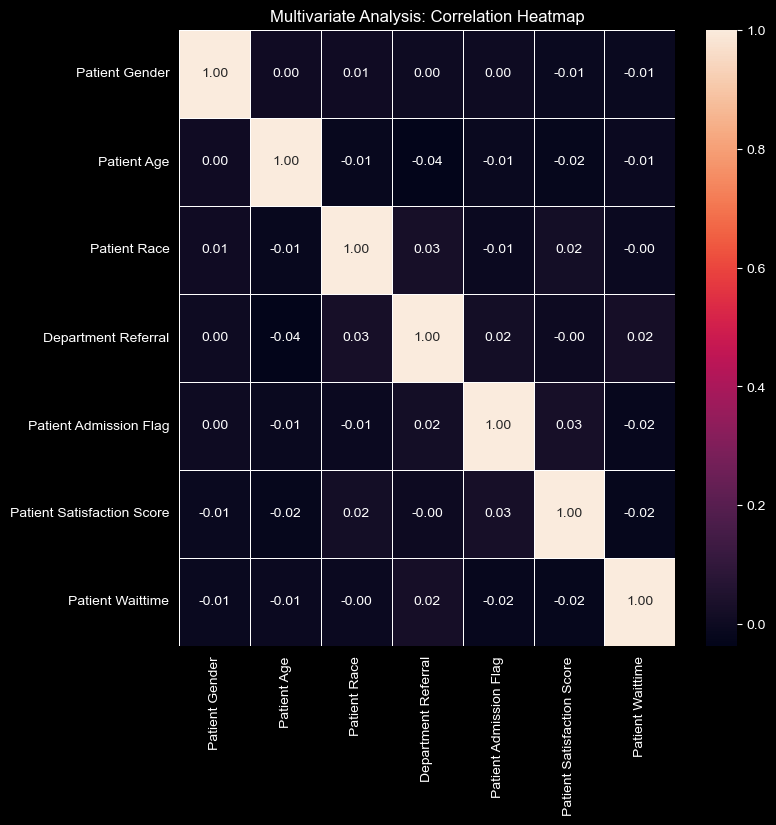

In [20]:
#heatmap for multivariate analysis
cols_to_exclude = [
    'Patient Id',
    'Patient Admission Date',
    'Patient Admission Time',
    'Merged'
]

df_multi = df.drop(columns=cols_to_exclude)

plt.figure(figsize=(8,8))
corr_matrix=df_multi.corr()
sns.heatmap(corr_matrix, annot=True,fmt='.2f', linewidths=0.5)
plt.title('Multivariate Analysis: Correlation Heatmap')
plt.show()

In [21]:
import pandas as pd
import numpy as np


# get upper triangle (boolean mask)
mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper = corr_matrix.where(mask)

# flatten to dataframe
corr_ranked = upper.unstack().reset_index()
corr_ranked.columns = ['Feature 1', 'Feature 2', 'Correlation']

# drop NaNs and sort
corr_ranked = corr_ranked.dropna()
corr_ranked = corr_ranked.reindex(
    corr_ranked['Correlation'].abs().sort_values(ascending=False).index
)

print(corr_ranked)


                     Feature 1                   Feature 2  Correlation
22         Department Referral                 Patient Age    -0.036411
23         Department Referral                Patient Race     0.027497
39  Patient Satisfaction Score      Patient Admission Flag     0.026550
36  Patient Satisfaction Score                 Patient Age    -0.023644
45            Patient Waittime         Department Referral     0.022514
47            Patient Waittime  Patient Satisfaction Score    -0.021183
46            Patient Waittime      Patient Admission Flag    -0.019832
37  Patient Satisfaction Score                Patient Race     0.018784
31      Patient Admission Flag         Department Referral     0.017441
15                Patient Race                 Patient Age    -0.012307
35  Patient Satisfaction Score              Patient Gender    -0.011408
42            Patient Waittime              Patient Gender    -0.010244
29      Patient Admission Flag                 Patient Age    -0